## What Are Tools in Agentic AI?
### 🛠️ What Are Tools in Agentic AI?
Tools are special functions or APIs that an agent can call to perform tasks beyond just generating text.
They are how an AI agent can “take actions” in the real world or fetch real-time information, not just respond with words.

# In Summary
### Tools in Agentic AI = Actions/functions/APIs the agent can use.
They make the agent much more powerful, letting it do things (not just chat).
Tools can be prebuilt (like web search) or custom (anything you code).
Tools you can explore: https://python.langchain.com/docs/integrations/tools/

In [1]:
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain.chat_models import init_chat_model
import gradio as gr

from langgraph.prebuilt import ToolNode, tools_condition

from dotenv import load_dotenv
load_dotenv(override=True)

C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
!pip install langchain-tavily

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Lenovo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
from langchain_tavily import TavilySearch

search_tool = TavilySearch(
    max_results=4,
    # topic="general",
    # include_answer=False,
    # include_raw_content=False,
    # include_images=False,
    # include_image_descriptions=False,
    # search_depth="basic",
    # time_range="day",
    # include_domains=None,
    # exclude_domains=None
)

In [4]:
search_tool.invoke("Tell me All union teritory of india")

{'query': 'Tell me All union teritory of india',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.britannica.com/topic/union-territory',
   'title': 'Union territory | India, Definition, History, & Facts - Britannica',
   'content': '* What is a union territory in India? * How are union territories different from states in India? * Who governs a union territory? * Can union territories have their own governments? * Why does India have union territories instead of making them states? Union territories are governed, in part or wholly, by the union government of India. There are eight union territories in India:. The Republic of India is made up of eight union territories and 28 states. In 1962 Pondicherry became a union territory of India. The Government of Union Territories Act of 1963 granted Pondicherry a state legislature. In 1961 it was merged into India and became a union territory. In 2019, after an outbreak of violence in the region 

In [5]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder=StateGraph(State)

In [6]:
from dotenv import load_dotenv
import os
from langchain_google_genai import ChatGoogleGenerativeAI

# Load env
load_dotenv()

# Get API key from .env
api_key = os.getenv("GOOGLE_API_KEY")

# Initialize LLM
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    google_api_key=api_key
)

In [7]:
tools = [search_tool]

llm_with_tools = llm.bind_tools(tools)

In [8]:
llm_with_tools.invoke(['What is the current wether of Delhi'])

AIMessage(content='', additional_kwargs={'function_call': {'name': 'tavily_search', 'arguments': '{"query": "current weather in Delhi"}'}, '__gemini_function_call_thought_signatures__': {'ff12650f-0ef9-4c89-9b91-c92c9fd32856': 'CuUEAb4+9vvpLDglTokbAsSb4oGQZw2QXRrm6QEIpH9l9to/uFlSCNJfEHa0P9i1WT9/9+t4fRinDRufi6tVk7GGE2Y8MJPgzM4wgrfJPFMQS7Ob2BX/BtZeEHT3hV9t59yapf+GJsXIw2/zPFw5QQmhptwT/P9mHBRnV954ZtP4UArA/w2GQoeZdlqIek2chMkWfqx+lB4HVm8qjWNEqn3yUdo+mgxxKtGgXoOL3cmHeYptOFbsPMsO8XW/7R7qd7sIJZzXTIkfV/EhuZY9fukbacrhaWfEvPE8C3tynHO8IbjoLEEVCIUapGH+EAS8R99cpdvtvrBDBEdYA78rPBQ0L4jlGF/X7V/u2tZ/BnUQ64DzK7S7w4uyM/MEugOGchxKmOvULN678msMfr5vLSrBP9OCvbJhR7w8+xHW4nKUuqZ5avHt4SrvQMjDCl+FXUrbignWPDYkRnVKugvOpxJkaRwqMXa01gt1o41Y2cTUDj3rHd50pWsKrg7D+nFpwWEMRvL3aluETytTuAnrjrKMzKv1DxY5h1ZJbXYjXOEpqzvhp1ehoAhTRdmfOlVAs3sxKbhmjCp19VcVu6xEyBTAke8Fs2WJPadlUk00tw9n+PqKu78c58Pbe0Z4z+TIydlwjxawiqEnVqUN3GjbxeHxwKKNtvTSTQiJoQQENDnDC6DPu9fhzb4fbZXPB6Hw24XJjxGjSVzN0rcN9Ut6et9VTXfEqhVGqKY1fXfieBW6DkqYIBCXg9hkEedS/UkRNZts

In [9]:
def chatbot(state: State) -> State:
  
    response= llm.bind_tools(tools).invoke(state['messages'])
    return {"messages": [response]}

In [10]:
tool_node = ToolNode(tools=tools)

In [11]:
graph_builder.add_node('chatbot',chatbot)
graph_builder.add_node('tools', tool_node)

In [12]:

graph_builder.add_edge(START, 'chatbot')
graph_builder.add_conditional_edges('chatbot', tools_condition)
graph_builder.add_edge('tools', 'chatbot')


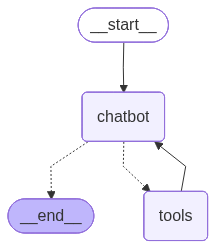

In [13]:

graph = graph_builder.compile()
graph

In [16]:
from langchain_core.messages import HumanMessage
# ▶️ Run
result = graph.invoke({
    "messages": [HumanMessage(content="Hii")]
})

print(result["messages"][-1].content)

Hello! How can I help you today?


In [17]:
graph_response = graph.invoke({'messages':['What is the current weather of Bangalore?']})
print(graph_response["messages"][-1].content)

[{'type': 'text', 'text': 'I am unable to provide the *current* weather for Bangalore as the search results are consistently showing weather forecasts for March 31, 2026, and not real-time data.\n\nAccording to the forecast for March 31, 2026, in Bangalore:\n*   The temperature is 33.2°C (91.8°F), but feels like 31.1°C (87.9°F).\n*   The condition is partly cloudy.\n*   Wind is 18.0 kph (11.2 mph) from the East.\n*   Humidity is 30%.', 'extras': {'signature': 'CuAGAb4+9vvUh3IHmcaUBKbtOHdKqd5eVMMNCDu51gWBR21cB6TFR3vbsiXBgjh0gibO8SpHJ5UGTBW7xgoITh6XdCujzgvx+EsAVmQks7zZYywGDSWmfoVszLh7jFNLizQ3uViBKJ680pkVdOjkm5G+U3GeYP4GUxnq6m0q+9EGqdnb4Q1tCOF3cr8U1PI6TygmB6zW69zlMzxoC3zl8iWTn/L7uSKLqhcMnyW/F+66alKZTvmzFK8e7oNrYQIkFa2HjudWNMzR4qVJVpIm7UaG5yYQ8u+HEZB0y0hFURzOczNTOmu+VoBJhyw/+I+ELqC/DK38tbQ1fYdwwTE/7KooBhfbEW+R1OgkLUt48fLvVTWljaxHE6rs0puhlVbw0O0FvSJTkioARiShnU4rbWGVxL2d+4atVYzoE3ftzlL0VePJCOswI2l8cWbnnh6/D5D7pUYxReSWBP7iZaECT4BdvuoGla5Q8/IVz4tPTnOza7xkwZTqV2gG6aY4brVWiJkUYB9xNbC1nqlvpYlCRzY

In [18]:

def chatbot_app(user_input: str, history)->str:
    initial_state = State(messages=[{'role':'user', 'content':user_input}])
    response = graph.invoke(initial_state)

    huamn_message = response['messages'][0].content
    ai_message = response['messages'][-1].content

    print("User :", huamn_message)
    print("AI :", ai_message)
    print("--"*20)

    return ai_message

In [20]:
gr.ChatInterface(
    fn=chatbot_app
).launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


User : hii
AI : Hello! How can I help you today?
----------------------------------------
User : my name is Harsh
AI : Hello Harsh. How can I help you today?
----------------------------------------
User : do you know my name 
AI : [{'type': 'text', 'text': "I do not know your name. I am a large language model, and I don't have access to personal information about you.", 'extras': {'signature': 'CrcCAb4+9vv0wj7mAoH5sn//E8U261rZUpPe7rgrjmwsEIdC5ZKdkz7pHqfpEQFKY9CxAD3QemqUYVED34QLEyb+3Sz34mXJP1FDmd6JTS2RrVMfrTF2ztWtvTycSwropubgjmFgGpZhaF86ifXQV0njSJB0CEmofiIDYvAxZ+HIAKyEeZfE3pIejAoVTrUkIYqCKbpVsSVBvV6vbkeM5n2yihnMJepXZqiqq3Wlt3X6gulz8dx/1XYWhd2+FgtrdShlW1GT34s2PbwnxaKiZcWqT2DNg4elh4v4EQalJzhLgcF6WK3DFuJsmcuKEUwTdJPJ2fFG1PI8r0GbT9IH9dV3shPlCsdbL5vFpYc+rmr0DN//pS6f41i8vMHZW7REJ8xzatKyLq4PPH8/ERSdx60CcGX5l7ejwFs='}}]
----------------------------------------
